In [1]:
pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.7 MB/s eta 0:00:00


In [3]:
from google_play_scraper import reviews, Sort
import pandas as pd

all_reviews = []
token = None

# Loop untuk mengambil data
for i in range(100):
    result, token = reviews(
        'id.flip',
        lang='id',
        country='id',
        sort=Sort.NEWEST,
        count=200,
        continuation_token=token
    )

    all_reviews.extend(result)

    # Berhenti jika tidak ada lagi review yang bisa diambil
    if not token:
        break
# 1. Buat DataFrame dari list all_reviews
df = pd.DataFrame(all_reviews)

# 2. Filter kolom yang diinginkan
df_filtered = df[['content', 'score']]

# 3. Simpan ke Excel
df_filtered.to_excel("review_flip.xlsx", index=False)

# 4. Print statistik
print("Total review berhasil diambil:", len(df))
print(df_filtered.head())

Total review berhasil diambil: 20000
                                             content  score
0                                              bagus      5
1  good job Aplikasi Flip transfer nya sangat mud...      5
2                                             mantap      5
3                                     ga bisa k3buka      5
4                                   sangat memuaskan      5


In [4]:
from google.colab import files
files.download("review_flip.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
!pip install matplotlib


In [6]:
import sklearn
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans']


In [7]:
#try to get structure information from the df
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  20000 non-null  object
 1   score    20000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 312.6+ KB


In [9]:
#We do not need data for column reviewId, userName, userImage so we will show only these column
df_filtered.loc[:,["content","score",]]


,content,score
0,bagus,5
1,good job Aplikasi Flip transfer nya sangat mud...,5
2,mantap,5
3,ga bisa k3buka,5
4,sangat memuaskan,5
...,...,...
19995,"pengajuan refund lama,salah masukkan nominal,l...",1
19996,Bagus,5
19997,Aplikasi paling berguna,5
19998,sangat membantu,5


In [10]:
#Check number of reviews scores
count = df_filtered['score'].value_counts()
df_count = pd.DataFrame(count)
df_count

,count
score,
5,13223
1,3856
4,1274
3,927
2,720


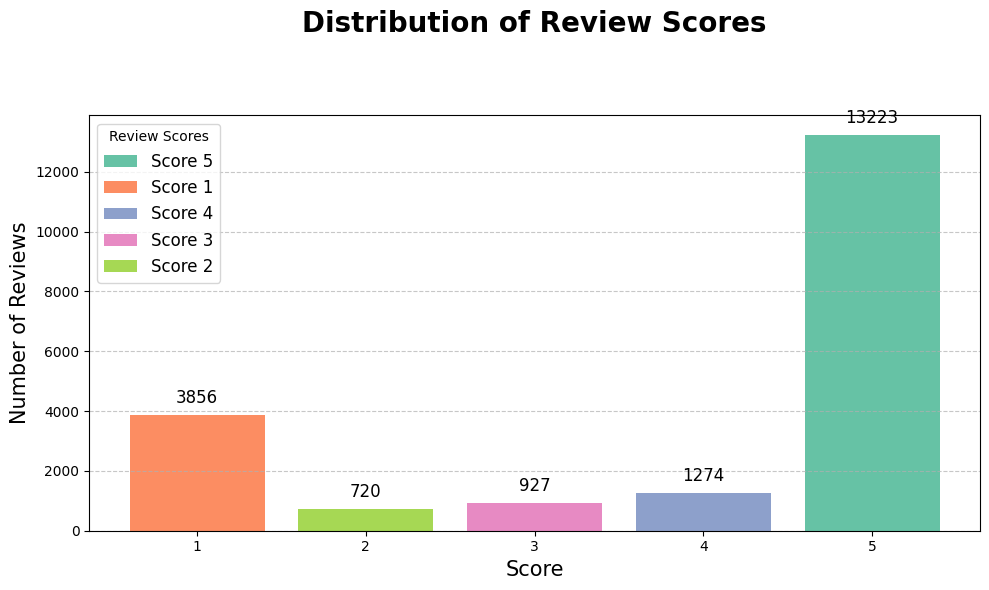

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Adjust the plot size
plt.figure(figsize=(10, 6))

# Define a color palette
palette = sns.color_palette("Set2", len(df_count))  # Set2 palette

# Create the bar plot with different colors for each score category
bars = plt.bar(df_count.index, df_count['count'], color=palette)

# Add axis labels and title
plt.title('Distribution of Review Scores', fontsize=20, fontweight='bold', pad=60) # Menambah pad ke 60
plt.xlabel('Score', fontsize=15)
plt.ylabel('Number of Reviews', fontsize=15)


# Add gridlines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add score labels above the bars
for bar in bars:
    yval = bar.get_height() # Get the height of the bar (the count value)
    xval = bar.get_x() + bar.get_width() / 2 # Calculate the horizontal center of the bar

    # Place the text label
    plt.text(xval, # X-coordinate: center of the bar
             yval + max(df_count['count']) * 0.02, # Y-coordinate: just above the bar
             str(yval), # The text to display (the count value)
             ha='center', # Horizontal alignment: center the text
             va='bottom', # Vertical alignment: align the bottom of the text with yval + offset
             fontsize=12,
             color='black')
# Add a legend (this is optional and could be removed if you don't need it)
plt.legend(bars, [f'Score {score}' for score in df_count.index], title='Review Scores', loc='upper left', fontsize=12)

# Show the plot
plt.tight_layout()  # Ensure everything fits within the plot
plt.show()